In [20]:
!pip install numpy pandas matplotlib seaborn scikit-learn

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

# ── Load Wine Dataset ────────────────────────────────────────
data = load_wine()
X, y = data.data, data.target

print("Dataset Shape:", X.shape)
print("Classes:", data.target_names)
print("Class Distribution:", {name: sum(y==i) for i, name in enumerate(data.target_names)})

Dataset Shape: (178, 13)
Classes: ['class_0' 'class_1' 'class_2']
Class Distribution: {np.str_('class_0'): np.int64(59), np.str_('class_1'): np.int64(71), np.str_('class_2'): np.int64(48)}


In [22]:
NUM_RUNS = 5
SEEDS    = [42, 7, 99, 2024, 13]

results = {"LogisticRegression": [], "SVM": []}

for run, seed in enumerate(SEEDS, 1):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # Logistic Regression
    lr = LogisticRegression(max_iter=10000, random_state=seed)
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)

    # SVM
    svm = SVC(kernel='rbf', random_state=seed)
    svm.fit(X_train, y_train)
    y_pred_svm = svm.predict(X_test)

    for model_name, y_pred in [("LogisticRegression", y_pred_lr),
                                ("SVM",               y_pred_svm)]:
        results[model_name].append({
            "Run"       : run,
            "Accuracy"  : accuracy_score(y_test, y_pred),
            "Precision" : precision_score(y_test, y_pred,average='macro'),
            "Recall"    : recall_score(y_test, y_pred,average='macro'),
            "F1 Score"  : f1_score(y_test, y_pred,average='macro'),
        })

    print(f"Run {run} [seed={seed}]  "
          f"LR acc={accuracy_score(y_test,y_pred_lr):.4f}  "
          f"SVM acc={accuracy_score(y_test,y_pred_svm):.4f}")

Run 1 [seed=42]  LR acc=0.9722  SVM acc=0.9722
Run 2 [seed=7]  LR acc=0.9722  SVM acc=0.9444
Run 3 [seed=99]  LR acc=1.0000  SVM acc=1.0000
Run 4 [seed=2024]  LR acc=0.9722  SVM acc=0.9722
Run 5 [seed=13]  LR acc=1.0000  SVM acc=1.0000


In [23]:
df_lr  = pd.DataFrame(results["LogisticRegression"])
df_svm = pd.DataFrame(results["SVM"])

print("===== Logistic Regression – Per-Run Results =====")
print(df_lr.to_string(index=False))

print("\n===== SVM – Per-Run Results =====")
print(df_svm.to_string(index=False))

===== Logistic Regression – Per-Run Results =====
 Run  Accuracy  Precision   Recall  F1 Score
   1  0.972222   0.977778 0.966667  0.970962
   2  0.972222   0.969697 0.976190  0.971781
   3  1.000000   1.000000 1.000000  1.000000
   4  0.972222   0.977778 0.966667  0.970962
   5  1.000000   1.000000 1.000000  1.000000

===== SVM – Per-Run Results =====
 Run  Accuracy  Precision   Recall  F1 Score
   1  0.972222   0.977778 0.966667  0.970962
   2  0.944444   0.958333 0.938889  0.945741
   3  1.000000   1.000000 1.000000  1.000000
   4  0.972222   0.977778 0.966667  0.970962
   5  1.000000   1.000000 1.000000  1.000000


In [24]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

summary = pd.DataFrame({
    "LR Mean"  : df_lr[metrics].mean(),
    "LR Std"   : df_lr[metrics].std(),
    "SVM Mean" : df_svm[metrics].mean(),
    "SVM Std"  : df_svm[metrics].std(),
})

print("========== AVERAGE PERFORMANCE (5 Runs) ==========")
print(summary.round(4).to_string())

========== AVERAGE PERFORMANCE (5 Runs) ==========
           LR Mean  LR Std  SVM Mean  SVM Std
Accuracy    0.9833  0.0152    0.9778   0.0232
Precision   0.9851  0.0140    0.9828   0.0176
Recall      0.9819  0.0170    0.9744   0.0259
F1 Score    0.9827  0.0158    0.9775   0.0229


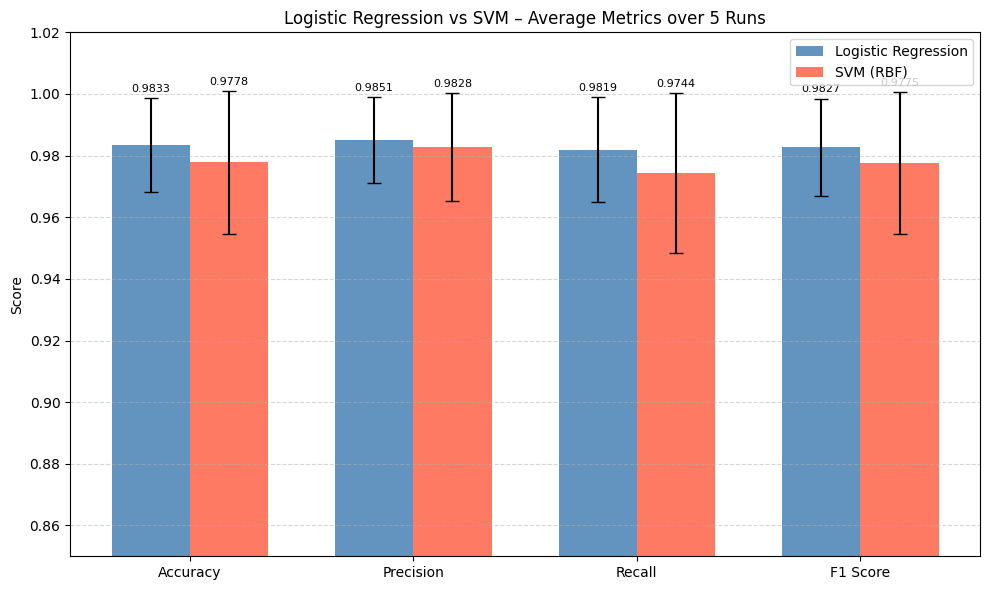

In [25]:
avg_lr  = df_lr[metrics].mean()
avg_svm = df_svm[metrics].mean()
std_lr  = df_lr[metrics].std()
std_svm = df_svm[metrics].std()

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, avg_lr,  width, yerr=std_lr,  label='Logistic Regression', color='steelblue', capsize=5, alpha=0.85)
bars2 = ax.bar(x + width/2, avg_svm, width, yerr=std_svm, label='SVM (RBF)',            color='tomato',    capsize=5, alpha=0.85)

ax.set_ylabel('Score')
ax.set_title('Logistic Regression vs SVM – Average Metrics over 5 Runs')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0.85, 1.02)
ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.bar_label(bars1, fmt='%.4f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.4f', padding=3, fontsize=8)
plt.tight_layout(); plt.show()

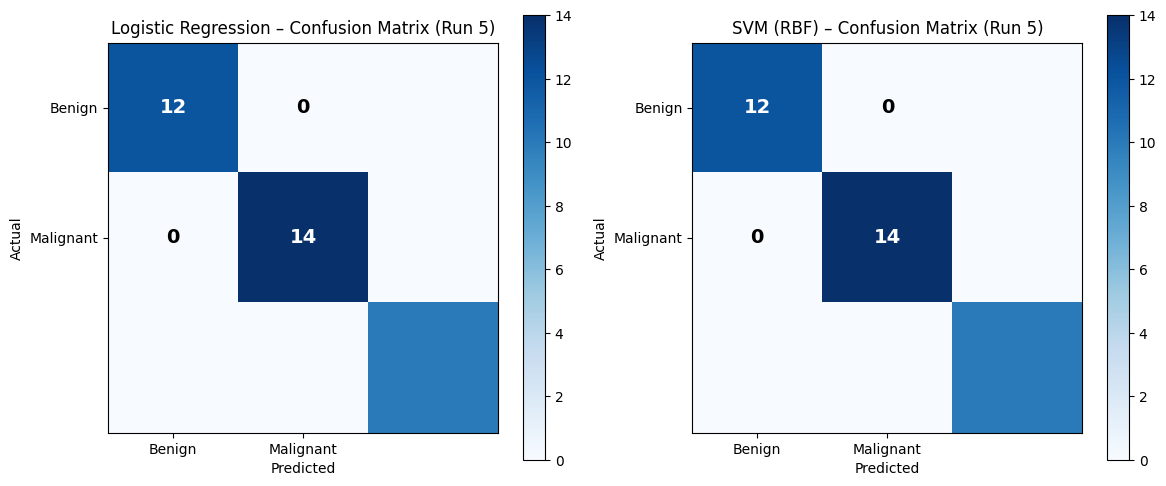

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, y_pred) in zip(axes,
        [("Logistic Regression", y_pred_lr),
         ("SVM (RBF)",           y_pred_svm)]):
    cm = confusion_matrix(y_test, y_pred)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    fig.colorbar(im, ax=ax)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Benign","Malignant"])
    ax.set_yticklabels(["Benign","Malignant"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black',
                    fontsize=14, fontweight='bold')
    ax.set_title(f'{name} – Confusion Matrix (Run 5)')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout(); plt.show()

In [27]:
print("===== Logistic Regression – Classification Report (Run 5) =====")
print(classification_report(y_test, y_pred_lr, target_names=data.target_names))

print("===== SVM – Classification Report (Run 5) =====")
print(classification_report(y_test, y_pred_svm, target_names=data.target_names))

===== Logistic Regression – Classification Report (Run 5) =====
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

===== SVM – Classification Report (Run 5) =====
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

